In [1]:
import numpy as np

Test things out!

$B_{mix}$ is a $10\times4$ matrix. I want to compute the kronecker product using $k_i$, a $100\times 100$ matrix. $n=100 \ p=10 \ q=4$.

In order to properly do a krylov space projection with the Lanczos algorithm, $k_i$ needs to be symmetric.

In [2]:
n = 100
p = 10
q = 4
B_mix = np.random.rand(p, q)
k_i = np.random.rand(n, n)
k_i = (k_i + k_i.T)

In [3]:
#check k_i
print(np.allclose(k_i, k_i.T))

True


Compress the $100 \times 100$ matrix to rank 3. The block size will be the target rank + the oversmpale, which will be ten. $V_1$ is a block of random vectors. We create an orthonormal matrix using the QR decomposition. 

In [4]:
#begin lanczos
k = 3 #rank target
over_sample = 10
p = k + over_sample #block size

#orthonormalize the block matrix
V1 = np.random.rand(n, p)
Q, R = np.linalg.qr(V1)
print(f"the orthonormal block matrix is: {Q}")

the orthonormal block matrix is: [[-0.12698247 -0.13627425  0.16861551 ...  0.0440078   0.06784859
   0.14613568]
 [-0.10284028 -0.03440225  0.01912157 ... -0.0622548  -0.12440187
  -0.12397393]
 [-0.15311338 -0.11301595 -0.05995651 ... -0.13419128  0.0249718
  -0.04740794]
 ...
 [-0.04440692  0.0288986  -0.06015541 ...  0.00297526 -0.07736086
   0.12049665]
 [-0.08649379  0.11783781 -0.05766237 ... -0.14754237  0.17645297
   0.00880096]
 [-0.02859304  0.06733627  0.22592534 ... -0.09880668  0.06809461
  -0.16608891]]


$V_j$ gets assigned the orthonormal component. $B_j \ and \ A_j$ will contain the block matrices for the tridiagonal matrix $T_m$. $m$ is the num of iterations being ran for. 

In [18]:
V_j = Q
A_orig = k_i
B_j = np.zeros((p, p))
V_prev = np.zeros((n, p))
A_list = []
B_list = []
V_list = []
m = n//p #num blocks
stop = 0
print(f"running for {m} iterations")
for j in range(1, m+1):
    W = A_orig @ V_j - V_prev @ B_j.T
    A_j = V_j.T @ W
    W = W - V_j @ A_j
    V_prev = V_j
    V_curr = V_j
    V_j, B_j = np.linalg.qr(W)
    if np.min(np.abs(np.diag(B_j))) < 1e-10:   # breakdown/rank-deficiency check
        print(f"Breakdown at iteration {j}, stopping.")
        stop = j - 1
        break
    V_list.append(V_curr)
    B_list.append(B_j)
    A_list.append(A_j)

m = stop

T_m = np.zeros((m*p, m*p))
for j in range(m):
    T_m[j*p:(j+1)*p, j*p:(j+1)*p] = A_list[j]

for j in range(m-1):
    T_m[(j+1)*p:(j+2)*p, j*p:(j+1)*p] = B_list[j]
    T_m[j*p:(j+1)*p, (j+1)*p:(j+2)*p] = B_list[j].T

print(f"The final matrix is {T_m}")

running for 7 iterations
Breakdown at iteration 7, stopping.
The final matrix is [[ 7.79745408e+01 -2.67764801e+01 -1.82297239e+01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-2.67764801e+01  8.62964112e+00  6.32260292e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.82297239e+01  6.32260292e+00  4.61557365e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  7.01370038e-01
   4.38244844e-03  2.02614307e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  4.38244844e-03
   3.04821497e-01  3.22946453e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  2.02614307e-01
   3.22946453e-01  4.61003735e-01]]


In [19]:
print(T_m.shape)

(78, 78)


In [20]:
theta, S = np.linalg.eigh(T_m) #eigen vetcors of T_m (mp, mp)
Q_m = np.hstack(V_list) #span of lanczos basis (n, mp)
V_hat = Q_m @ S #ritz vectors of (n, mp) shape

In [21]:
Q_m = np.hstack(V_list)
orth_error = np.linalg.norm(Q_m.T @ Q_m - np.eye(Q_m.shape[1]))
print(f"Orthogonality error: {orth_error}")  # should be ~1e-10, not large

Orthogonality error: 1.1363006476753754e-08


In [22]:
print(Q_m.shape)

(100, 78)


In [23]:
#get top k ritz values
idx = np.argsort(theta)[::-1][:k]
lambda_k = theta[idx]
V_k = V_hat[:, idx]
A_approx = V_k @ np.diag(lambda_k) @ V_k.T

In [24]:
print(f"the 3-rank approx matrix is: {A_approx}")

the 3-rank approx matrix is: [[1.0165617  0.93171899 1.03003119 ... 0.98313177 0.96931253 0.880346  ]
 [0.93171899 1.11363907 1.19565789 ... 1.04244349 0.9236669  0.88684923]
 [1.03003119 1.19565789 1.28994305 ... 1.15860106 1.03438937 0.98874627]
 ...
 [0.98313177 1.04244349 1.15860106 ... 1.28679505 1.14040262 1.09061813]
 [0.96931253 0.9236669  1.03438937 ... 1.14040262 1.05942465 0.98911425]
 [0.880346   0.88684923 0.98874627 ... 1.09061813 0.98911425 0.93484006]]


In [25]:
print(A_approx.shape)

(100, 100)


In [26]:
error_fro = np.linalg.norm(A_approx - A_orig, 'fro')
print(f"The error of the compression is {error_fro}")
assert error_fro <= np.linalg.norm(A_orig, 'fro'), "Error exceeds theoretical bound — something's broken"

The error of the compression is 39.82965336330037


In [27]:
print(f"A_orig frob norm is: {np.linalg.norm(A_orig, 'fro')}")

A_orig frob norm is: 108.41821778385643


# calculating Error for Kronecker product
We will be calculating the following: $(A \otimes B) \ - \ (A_{approx} \otimes B) \ = \ (A \ - \ A_{approx}) \otimes B$. 

For the frobenius norm, $\|(A \ - \ A_{approx}) \otimes B\|_F$ will look like: $$ \|A \ - \ A_{Approx} \|_F * \| B \|_F$$

# Relative Error calculations

$$ \frac{ \|( A \otimes B) - (A_{Approx} \otimes B) \|_F}{\| A \otimes B \|_F} = \frac{\|A-A_{Approx}\|_F}{\|A\|_F} $$

In [28]:
A_error = np.linalg.norm(A_orig - A_approx, 'fro')
B_error = np.linalg.norm(B_mix, 'fro')
kron_error = A_error * B_error
print(f"The error in the kronekcer product is {kron_error}")

The error in the kronekcer product is 153.99990432260887


In [29]:
#sanity check 
K_xx_approx = np.kron(B_mix, A_approx)
K_xx = np.kron(B_mix, A_orig)
error = np.linalg.norm(K_xx - K_xx_approx, "fro")
print(f"The error is {error}")

The error is 153.99990432260884


In [32]:
A_orig_err = np.linalg.norm(A_orig, 'fro')
rel_error = A_error / A_orig_err
print(f"relative error for a rank 3 compression of a kronecker operand of size 100x100 is: {rel_error:.2%}")

relative error for a rank 3 compression of a kronecker operand of size 100x100 is: 36.74%


In [33]:
#check overall energy captured from matrix
energy_captured = 1 - rel_error**2   # since rel_error^2 = 1 - (energy fraction)
print(f"Energy captured: {energy_captured:.2%}")

Energy captured: 86.50%


In [34]:
#Eckart Young calc for best possible error for compression to rank 3
sigma_true = np.linalg.eigvalsh(A_orig)[::-1]
optimal_error = np.sqrt(np.sum(sigma_true[k:]**2))   # best possible rank-k error
optimal_rel_error = optimal_error / np.linalg.norm(A_orig, 'fro')

Matplotlib is building the font cache; this may take a moment.


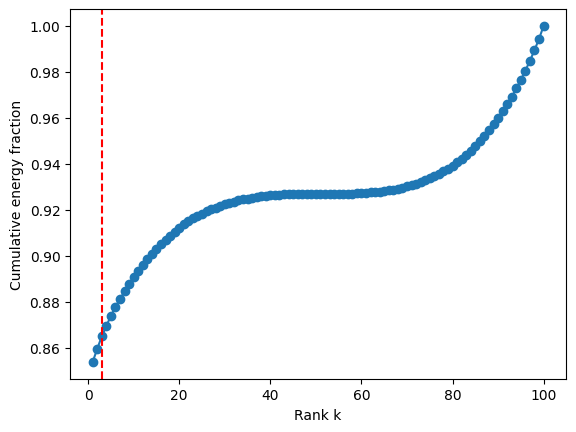

Energy at rank 3: 86.50%


In [35]:
import matplotlib.pyplot as plt

cumulative_energy = np.cumsum(sigma_true**2) / np.sum(sigma_true**2)
plt.plot(range(1, len(sigma_true)+1), cumulative_energy, marker='o')
plt.axvline(x=3, color='r', linestyle='--')
plt.xlabel('Rank k')
plt.ylabel('Cumulative energy fraction')
plt.show()

print(f"Energy at rank 3: {cumulative_energy[2]:.2%}")